For all ball flying throught the air.

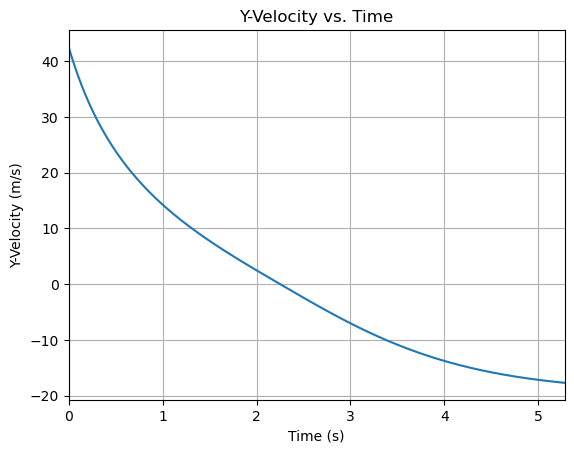

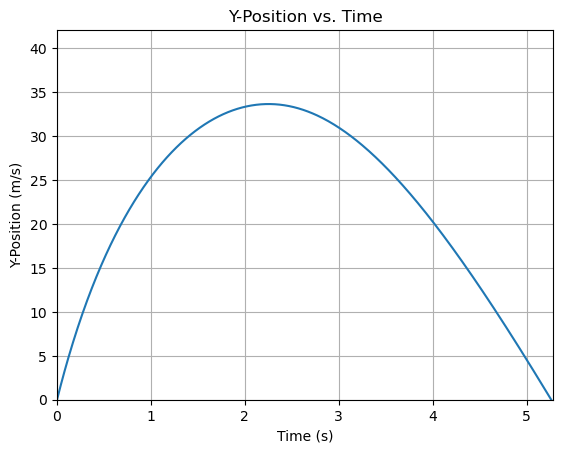

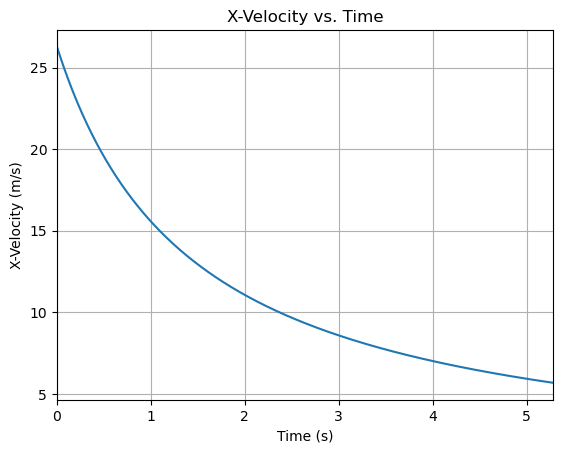

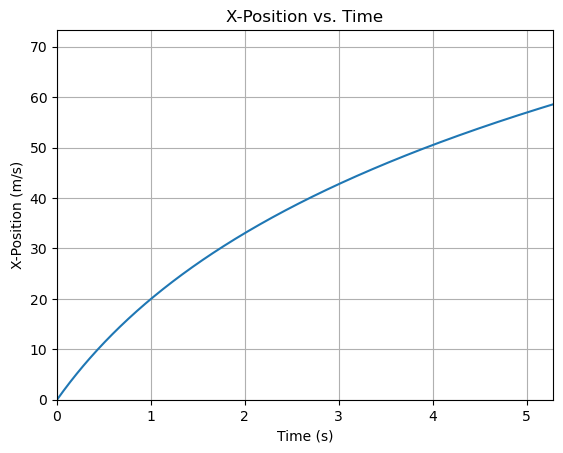

In [1]:
#Importing libraries.
import numpy as np
import matplotlib.pyplot as plt

#Initial conditions.
Cd = 0.47
A = 0.038
p = 1.225
m = 0.42
g = 9.81
v = 50
angle = 45

#Creating time step and time array.
dt = 0.01
t = np.arange(0, 10, dt)

#Initializes the Y-direction arrays for position and velocity, as well as initial conditions.
py_array = np.zeros(np.size(t))
vy_array = np.zeros(np.size(t))
vy_array[0] = v*np.sin(angle)

#Y-direction calculations for position and velocity arrays.
i = 1
while (py_array[i-3] >= 0) and (i <= (np.size(t) - 1)):
    fy_drag = -0.5 * Cd * p * A * vy_array[i-1]*np.abs(vy_array[i-1])
    ay = fy_drag / m
    vy_change = ay * dt
    vy_array[i] = vy_array[i-1] + vy_change - g*dt
    py_array[i] = -0.5*g*dt**2 + vy_array[i-1]*dt + py_array[i-1]
    i += 1

#Finds where the y_pos crosses the x-intercept, while disregarding the initial y-position. With this index that is returned as an array, the other arrays are concatonated to reduce unnecessary information.
index = np.argwhere(py_array[1:]<=0) + 2
vy_array = vy_array[:index[0][0]+2]
py_array = py_array[:index[0][0]+2]
t = t[:index[0][0]+2]

#Initializes the X-direction arrays for position and velocity, as well as initial conditions (Down here since our time array is concatonated based on the time of X-intercept).
px_array = np.zeros(np.size(t))
vx_array = np.zeros(np.size(t))
vx_array[0] = v*np.cos(angle)

#X-direction calculations for position and velocity arrays.
for i in range(1, index[0][0]+2):
    fx_drag = -0.5 * Cd * p * A * vx_array[i-1]*np.abs(vx_array[i-1])
    ax = fx_drag / m
    vx_change = ax * dt
    vx_array[i] = vx_array[i-1] + vx_change
    px_array[i] = 0.5*ax*dt**2 + vx_array[i-1]*dt + px_array[i-1]

#Y-direction plots.
plt.figure()
plt.xlabel("Time (s)")
plt.ylabel("Y-Velocity (m/s)")
plt.title("Y-Velocity vs. Time")
plt.xlim(0, t[index[0][0]])
plt.grid()
plt.plot(t, vy_array)

plt.figure()
plt.xlabel("Time (s)")
plt.ylabel("Y-Position (m/s)")
plt.ylim(0, np.max(py_array)*1.25)
plt.xlim(0, t[index[0][0]])
plt.title("Y-Position vs. Time")
plt.grid()
plt.plot(t, py_array)

#X-direction plots.
plt.figure()
plt.xlabel("Time (s)")
plt.ylabel("X-Velocity (m/s)")
plt.title("X-Velocity vs. Time")
plt.xlim(0, t[index[0][0]])
plt.grid()
plt.plot(t, vx_array)

plt.figure()
plt.xlabel("Time (s)")
plt.ylabel("X-Position (m/s)")
plt.ylim(0, np.max(px_array)*1.25)
plt.xlim(0, t[index[0][0]])
plt.title("X-Position vs. Time")
plt.grid()
plt.plot(t, px_array)